<hr />

### Patient Readmission Risk Predictor 

<hr />

<p>Applied Artificial Intelligence</p>

<p>Prof. Maryam Abbasi</p>

<p>Escola Superior de Gestão e Tecnologia - Instituto Politécnico de Santarém</p>

<hr />

<p>Isaac Mendes - </p>

<p>Rodrigo Calado - 250001513</p>

<p>Tiago Amorim - </p>

<hr />

#### Imports Install

In [1]:
#!pip install scikit-learn pandas matplotlib seaborn

<hr />

#### Loading Imports and Librarys

In [2]:
# ── Environment Setup ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier

# Reproducibility
np.random.seed(42)
RANDOM_STATE=42

print(" All libraries imported successfully!")
print(f"   numpy  : {np.__version__}")
print(f"   pandas : {pd.__version__}")

 All libraries imported successfully!
   numpy  : 2.2.5
   pandas : 2.3.3


<hr />

#### Starting to Separate All the Dataset, Loading the "mapping" Dataset to Get All Columns Associated with Main Data Dataset

#### After That, We Need to Divide in "Blocks" for a Better Distinguish and Convert Them to Numeric to Get The Real Value from the String Value in the "mapping" Dataset

#### At the End, We Gonna Load All Data Dataset by Chuncks Because We Don't Know How Much Size It Has and Also for Computer Resources Performance It's Much Better

In [3]:
## Datasets
path_prrp_data = "data/diabetic_data.csv"
path_prrp_map = "data/IDS_mapping.csv"

## Arguments
chunck_size = 1000
prrp_map = pd.read_csv(path_prrp_map, header=None)
prrp_df = []

## Find Empty Rows
empty_rows = prrp_map[prrp_map.isna().all(axis=1)].index.tolist()

## Separate Between 3 Blocks - admission_type, discharge_disposition, admission_source
b1 = prrp_map.iloc[0:empty_rows[0], :] ## 1st Block - Row 0 to First Empty Row
b2 = prrp_map.iloc[empty_rows[0]+1:empty_rows[1], :] ## 2nd Block - Between First and Second Empty Rows
b3 = prrp_map.iloc[empty_rows[1]+1:, :] ## 3rd Block - After Second Empty Row to the End

## Assing Correct Header to Each Block
b1.columns, b2.columns, b3.columns = ["admission_type_id", "description"], ["discharge_disposition_id", "description"], ["admission_source_id", "description"]

## Convert ID for Numeric (Ignore Empty Rows and NULL)
b1["admission_type_id"] = pd.to_numeric(b1["admission_type_id"], errors="coerce").astype("Int64")
b2["discharge_disposition_id"] = pd.to_numeric(b2["discharge_disposition_id"], errors="coerce").astype("Int64")
b3["admission_source_id"] = pd.to_numeric(b3["admission_source_id"], errors="coerce").astype("Int64")

## Rename Column "description" to Distinct Names
b1 = b1.rename(columns={"description": "admission_type"})
b2 = b2.rename(columns={"description": "discharge_disposition"})
b3 = b3.rename(columns={"description": "admission_source"})

## Process All Dataset Chunck by Chunck (Better Resources Performance)
prrp_chuncks = []
for chunck in pd.read_csv(path_prrp_data, chunksize=chunck_size):
    for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
        chunck[col] = pd.to_numeric(chunck[col], errors="coerce").astype("Int64")

    chunck = chunck.merge(b1, on="admission_type_id", how="left")
    chunck = chunck.merge(b2, on="discharge_disposition_id", how="left")
    chunck = chunck.merge(b3, on="admission_source_id", how="left")
    prrp_chuncks.append(chunck)

prrp_df = pd.concat(prrp_chuncks, ignore_index=True)

<hr />

#### EDA Progress

In [4]:
## General Visualization
print("General Visualization:")
print(prrp_df.shape)
print(prrp_df.info())

print(20*"=")

## Numerical Statistics
print("Numerical Statistics:")
print(prrp_df.describe().T)

## Categorical Statistics
print("Categorical Statistics:")
print(prrp_df.describe(include="object").T)

print(20*"=")

## Missing by Column (Feature)
missing = prrp_df.isna().sum().sort_values(ascending=False)
print("Missing by Feature:", missing)

print(20*"=")

## Target Variable Distribution - "readmitted"
print(prrp_df["readmitted"].value_counts(dropna=False))
print(prrp_df["readmitted"].value_counts(normalize=True))

print(20*"=")

## New Column with Readmission Binary (<30)
prrp_df["readmitted_30"] = prrp_df["readmitted"].eq("<30").astype(int)
print(prrp_df["readmitted_30"].value_counts(normalize=True))

print(20*"=")

## Already Decoded Admission Type Distribution
print(prrp_df["admission_type"].value_counts(dropna=False))
print(prrp_df["discharge_disposition"].value_counts(dropna=False))
print(prrp_df["admission_source"].value_counts(dropna=False))

print(20*"=")

## Principal Numerical Features
numerical_cols = prrp_df.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
print(prrp_df[numerical_cols].describe().T)

print(20*"=")

## Principal Categorial Features
categorical_cols = prrp_df.select_dtypes(include=["object"]).columns.tolist()
print(prrp_df[categorical_cols].describe().T)

print(20*"=")

## Relation Between Categorial Features vs Readmission
categorical_cols = [c for c in categorical_cols if c not in ["readmitted"]]

for col in categorical_cols:
    print("Column: ", col)
    tab = prrp_df.groupby(col)["readmitted_30"].agg(["count", "mean"]).rename(columns={"mean": "rate_admitted_30"}).sort_values("rate_admitted_30", ascending=False)
    tab.head(10)

print(20*"=")

## Relation Between Numerical Features vs Readmission
for col in numerical_cols:
    if col != "readmitted_30":
        print("Column: ", col)
        print(prrp_df.groupby("readmitted_30")[col].describe()[["mean", "std", "25%", "50%", "75%"]])

General Visualization:
(101766, 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  Int64 
 7   discharge_disposition_id  101766 non-null  Int64 
 8   admission_source_id       101766 non-null  Int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures         

<hr />

#### Train & Test Split & Fit

In [6]:
drop_cols = ["encounter_id", "patient_nbr", "readmitted"]
X = prrp_df.drop(columns=drop_cols + ["readmitted_30"], errors="ignore")
y = prrp_df["readmitted_30"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train!
X_test_scaled  = scaler.transform(X_test)        # apply same scaling to test

n_samples = X.shape[0] ## Number of rows will represent number of samples
n_features = X.shape[1] ## Number of columns will represent number of features
print(f"1. Samples: {n_samples}  |  Features: {n_features}")

1. Samples: 101766  |  Features: 2477


<hr />

#### Features Importance - RandomForest + LogisticRegression

In [11]:
## Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, max_features="sqrt", random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

feature_names = X.columns.to_numpy()
importances = rf_model.feature_importances_
idx = np.argsort(importances)[::-1]

print("(First 30) Features Importance by RandomForest\n")
for i in idx[:30]:
    print(f"{feature_names[i]:50s} {importances[i]:.4f}")

print(20 * "=")

## Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

coefs_lr = lr_model.coef_[0]
coef_prrp_df = (pd.DataFrame({"feature": feature_names, "coef": coefs_lr}).assign(abs_coef=lambda d: d["coef"].abs()).sort_values("abs_coef", ascending=False))

print("(First 30) Features Importance by LogisticRegression\n", coef_prrp_df.head(30))

(First 30) Features Importance by RandomForest

number_inpatient                                   0.1334
discharge_disposition_Discharged/transferred to another rehab fac including rehab units of a hospital . 0.0512
number_emergency                                   0.0337
discharge_disposition_Discharged to home           0.0297
num_medications                                    0.0294
discharge_disposition_id                           0.0285
time_in_hospital                                   0.0197
number_diagnoses                                   0.0189
num_lab_procedures                                 0.0187
discharge_disposition_Expired                      0.0186
diag_1_V58                                         0.0181
discharge_disposition_Discharged/transferred to SNF 0.0145
number_outpatient                                  0.0136
discharge_disposition_Discharged/transferred to another short term hospital 0.0099
insulin_No                                         0.0099
num

<hr />

#### Correlations + Heatmap

readmitted_30               1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
patient_nbr                 0.007893
admission_source_id         0.005820
encounter_id               -0.008519
admission_type_id          -0.011651
num_procedures             -0.012227
Name: readmitted_30, dtype: float64


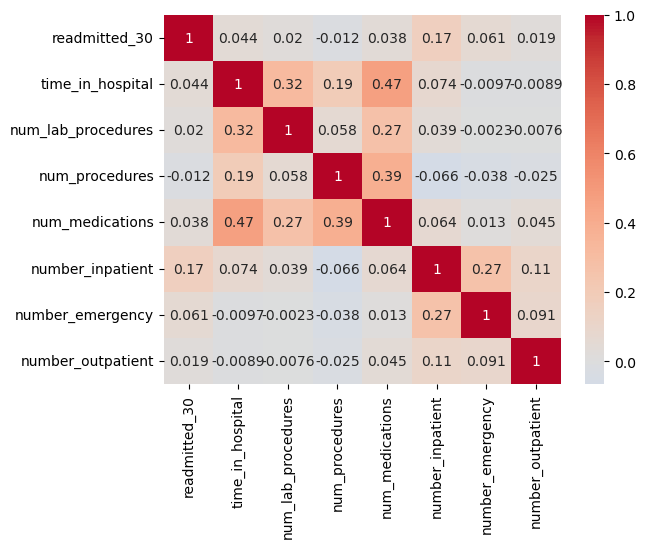

In [12]:
prrp_corr = prrp_df[numerical_cols].corr()
print(prrp_corr["readmitted_30"].sort_values(ascending=False).head(20))

## Heatmap
subset = ["readmitted_30", "time_in_hospital", "num_lab_procedures",
          "num_procedures", "num_medications",
          "number_inpatient", "number_emergency", "number_outpatient"]

subset = [c for c in subset if c in prrp_df.columns]
corr_subset = prrp_df[subset].corr()

sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.show()


<hr />

#### Some Basic Plots for Start Analysis

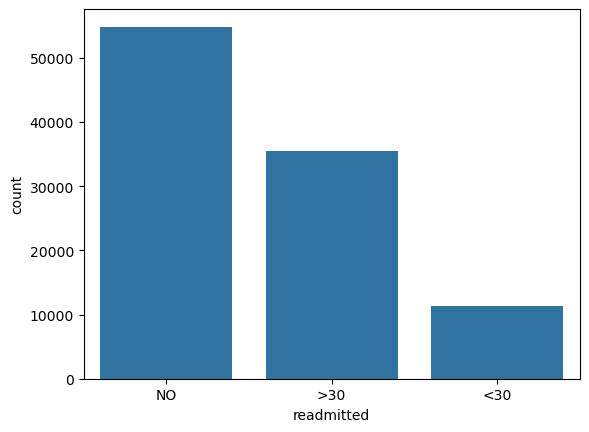

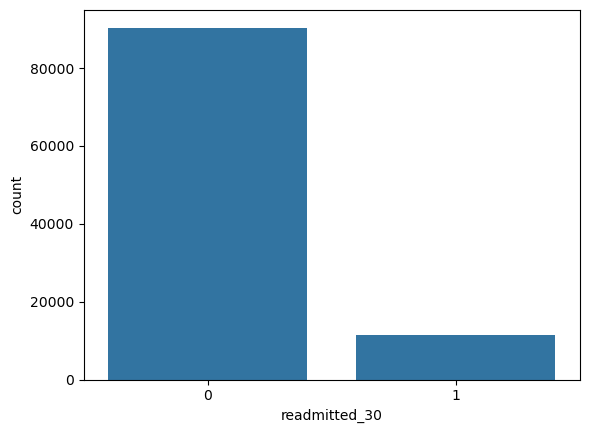

In [13]:
## Readmitted Count Plot
sns.countplot(x="readmitted", data=prrp_df)
plt.show()

## Readmitted Within 30 Days Plot
sns.countplot(x="readmitted_30", data=prrp_df)
plt.show()
